# Pré-processamento e Modelagem
## Breast Cancer Wisconsin Dataset

Este notebook tem como objetivo executar as etapas de **pré-processamento** dos dados e o **treinamento de modelos de Machine Learning** para classificação binária (benigno vs maligno).

Etapas principais:
1. Limpeza e preparação dos dados
2. Codificação da variável alvo
3. Divisão em treino e teste
4. Padronização das variáveis
5. Treinamento e comparação de modelos


In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


## 1. Carregamento e limpeza inicial dos dados

Nesta etapa, carregamos o dataset e removemos colunas que não agregam valor preditivo (`id` e `Unnamed: 32`).


In [25]:
df = pd.read_csv("../data/breast_cancer_dataset.csv")

# Remover colunas irrelevantes
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

df.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Codificação da variável alvo

A variável alvo `diagnosis` está rotulada como `B` (benigno) e `M` (maligno).  
Nesta etapa, convertemos o target para formato numérico para permitir o treinamento dos modelos.


In [31]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

y = y.map({"B": 0, "M": 1})
y.value_counts()



diagnosis
0    357
1    212
Name: count, dtype: int64

## 3. Divisão em Treino e Teste

Dividimos o dataset em conjuntos de treino e teste para avaliar a capacidade de generalização dos modelos.  
Também utilizamos estratificação para manter a proporção das classes em ambos os conjuntos.


In [33]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # divide a proporção de classes B e M
)


## 4. Modelo baseline (sem PCA)

Como baseline, treinaremos um modelo simples utilizando **padronização (StandardScaler)** e **Regressão Logística**, que é adequada para classificação binária e sensível à escala das variáveis.


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe_baseline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_baseline.fit(X_train, y_train)



Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

## 5. Avaliação do modelo baseline

A seguir, avaliamos o desempenho do modelo utilizando métricas adequadas ao contexto do problema, incluindo Accuracy, Recall e F1-score.


In [39]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

pred_baseline = pipe_baseline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_baseline))
print("Recall:", recall_score(y_test, pred_baseline))
print("F1-score:", f1_score(y_test, pred_baseline))


Accuracy: 0.9649122807017544
Recall: 0.9285714285714286
F1-score: 0.9512195121951219


              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



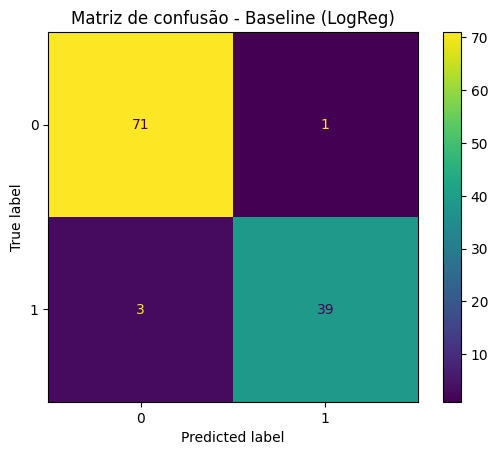

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, pred_baseline))

cm = confusion_matrix(y_test, pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusão - Baseline (LogReg)")
plt.show()



**Observações a partir da avaliação do modelo baseline:**

- O modelo apresentou **acurácia geral de 0.96**, indicando bom desempenho no conjunto de teste.

- Para a classe **1 (maligno)**, obteve-se:
  - **Recall = 0.93**, ou seja, aproximadamente 93% dos casos malignos foram corretamente identificados.
  - **F1-score = 0.95**, sugerindo bom equilíbrio entre precisão e recall.

- Como se trata de um problema médico, o **Recall da classe maligna** é especialmente relevante, pois falsos negativos (casos malignos classificados como benignos) podem gerar risco elevado. O valor obtido indica que o modelo baseline já possui uma boa capacidade de detecção.

- A diferença entre Precision e Recall na classe 1 sugere que ainda existem alguns erros do tipo **falso negativo**, o que reforça a importância de testar outras abordagens (ex.: PCA, seleção de variáveis e comparação com outros modelos) visando melhoria do Recall.


## 6. Experimento: Redução de dimensionalidade com PCA

Com base na análise de correlação realizada no EDA, observou-se alta correlação entre variáveis de 'medidas', sugerindo redundância de informação.  
Nesta etapa, testamos o uso de PCA no pipeline para reduzir dimensionalidade e comparamos o desempenho com o baseline.


In [63]:
from sklearn.decomposition import PCA

pipe_pca_90 = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.90, random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_pca_90.fit(X_train, y_train)



Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.9, random_state=42)),
                ('model', LogisticRegression(max_iter=1000))])

In [64]:
pred_pca_90 = pipe_pca_90.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_pca_90))
print("Recall:", recall_score(y_test, pred_pca_90))
print("F1-score:", f1_score(y_test, pred_pca_90))

print("\nClassification Report:\n")
print(classification_report(y_test, pred_pca_90))



Accuracy: 0.9736842105263158
Recall: 0.9523809523809523
F1-score: 0.963855421686747

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [74]:
n_comp = pipe_pca90_robust.named_steps["pca"].n_components_
print("Número de componentes (PCA 90%):", n_comp)



Número de componentes (PCA 90%): 7


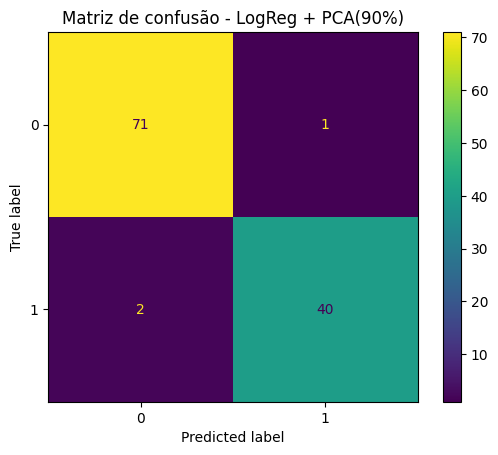

In [65]:
cm = confusion_matrix(y_test, pred_pca_90)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusão - LogReg + PCA(90%)")
plt.show()



## 6.3 Experimento: substituição do StandardScaler por RobustScaler (mantendo PCA 90%)

Neste experimento, mantemos o PCA configurado para 90% da variância explicada e substituímos o **StandardScaler** pelo **RobustScaler**, que é menos sensível a valores extremos.
O objetivo é avaliar se essa troca melhora o desempenho do modelo, especialmente em métricas como Recall e F1-score.



In [72]:
from sklearn.preprocessing import RobustScaler

pipe_pca90_robust = Pipeline(steps=[
    ("scaler", RobustScaler()),
    ("pca", PCA(n_components=0.90, random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_pca90_robust.fit(X_train, y_train)
pred_pca90_robust = pipe_pca90_robust.predict(X_test)


In [73]:
print("Accuracy:", accuracy_score(y_test, pred_pca90_robust))
print("Recall:", recall_score(y_test, pred_pca90_robust))
print("F1-score:", f1_score(y_test, pred_pca90_robust))

print("\nClassification Report:\n")
print(classification_report(y_test, pred_pca90_robust))



Accuracy: 0.9824561403508771
Recall: 0.9523809523809523
F1-score: 0.975609756097561

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [88]:
results = pd.DataFrame([
    {
        "Modelo": "Baseline (StandardScaler + LogReg)",
        "Accuracy": accuracy_score(y_test, pred_baseline),
        "Recall": recall_score(y_test, pred_baseline),
        "F1": f1_score(y_test, pred_baseline)
    },
    {
        "Modelo": "PCA 90% (StandardScaler + PCA + LogReg)",
        "Accuracy": accuracy_score(y_test, pred_pca_90),
        "Recall": recall_score(y_test, pred_pca_90),
        "F1": f1_score(y_test, pred_pca_90)
    },
    {
        "Modelo": "PCA 90% (RobustScaler + PCA + LogReg)",
        "Accuracy": accuracy_score(y_test, pred_pca90_robust),
        "Recall": recall_score(y_test, pred_pca90_robust),
        "F1": f1_score(y_test, pred_pca90_robust)
    },
])

results




,Modelo,Accuracy,Recall,F1
0,Baseline (StandardScaler + LogReg),0.964912,0.928571,0.951220
1,PCA 90% (StandardScaler + PCA + LogReg),0.973684,0.952381,0.963855
2,PCA 90% (RobustScaler + PCA + LogReg),0.982456,0.952381,0.975610


## 7. Teste de modelos adicionais

Além da Regressão Logística, testamos outros modelos para comparar desempenho no diagnóstico:
- **Random Forest** (modelo baseado em árvores, robusto e interpretável via feature importance)
- **SVM** (modelo baseado em margem, geralmente performa bem nesse tipo de dataset)

O objetivo é comparar os modelos priorizando métricas relevantes ao contexto médico, como **Recall** e **F1-score**.



### 7.1.1 Random Forest - Treinamento



In [91]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)



Random Forest
Accuracy: 0.9736842105263158
Recall: 0.9285714285714286
F1-score: 0.9629629629629629

               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



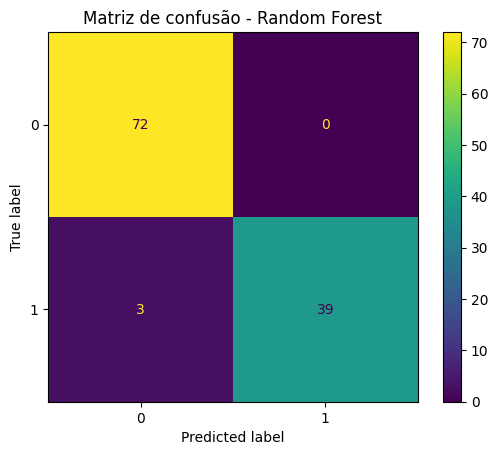

In [92]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1-score:", f1_score(y_test, pred_rf))
print("\n", classification_report(y_test, pred_rf))

cm = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusão - Random Forest")
plt.show()


### 7.1.5 Random Forest - Interpretação (Feature Importance)

Como forma de interpretação do modelo, analisamos quais variáveis tiveram maior influência nas previsões do Random Forest por meio de **feature importance**.



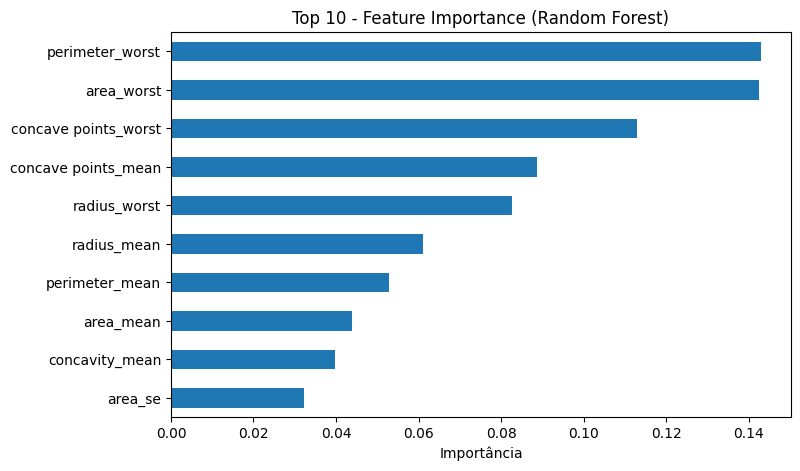

perimeter_worst         0.143121
area_worst              0.142449
concave points_worst    0.112978
concave points_mean     0.088663
radius_worst            0.082649
radius_mean             0.061043
perimeter_mean          0.052928
area_mean               0.043820
concavity_mean          0.039761
area_se                 0.032237
dtype: float64

In [94]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 - Feature Importance (Random Forest)")
plt.xlabel("Importância")
plt.show()

importances.head(10)


**Observações:**
- O Random Forest apresentou bom desempenho no conjunto de teste.
- Em contexto médico, é importante observar especialmente o **Recall** da classe maligna (1), pois falsos negativos são críticos.
- A análise de feature importance ajuda a entender quais características do exame contribuíram mais para a decisão do modelo.


### 7.2.1 SVM - Treinamento

O SVM (Support Vector Machine) é um modelo baseado em margem, que costuma performar bem em problemas de classificação binária.  
Como depende de distâncias e escalas, utilizamos **StandardScaler** no pipeline.


In [96]:
from sklearn.svm import SVC

pipe_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

pipe_svm.fit(X_train, y_train)
pred_svm = pipe_svm.predict(X_test)


SVM (StandardScaler)
Accuracy: 0.9736842105263158
Recall: 0.9285714285714286
F1-score: 0.9629629629629629

               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



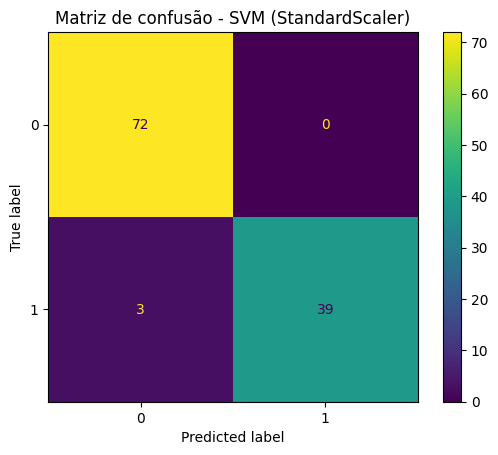

In [97]:
print("SVM (StandardScaler)")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Recall:", recall_score(y_test, pred_svm))
print("F1-score:", f1_score(y_test, pred_svm))
print("\n", classification_report(y_test, pred_svm))

cm = confusion_matrix(y_test, pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusão - SVM (StandardScaler)")
plt.show()


## 7.3 Comparação final (melhores modelos)

A seguir, comparamos os melhores resultados obtidos para cada abordagem.  
Como o objetivo é suporte ao diagnóstico médico, damos prioridade às métricas **Recall** e **F1-score**.


In [101]:
best_models = pd.DataFrame([
    {
        "Modelo": "LogReg (RobustScaler + PCA 90%)",
        "Accuracy": accuracy_score(y_test, pred_pca90_robust),
        "Recall": recall_score(y_test, pred_pca90_robust),
        "F1": f1_score(y_test, pred_pca90_robust)
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": accuracy_score(y_test, pred_rf),
        "Recall": recall_score(y_test, pred_rf),
        "F1": f1_score(y_test, pred_rf)
    },
    {
        "Modelo": "SVM (StandardScaler)",
        "Accuracy": accuracy_score(y_test, pred_svm),
        "Recall": recall_score(y_test, pred_svm),
        "F1": f1_score(y_test, pred_svm)
    }
]).sort_values("Recall", ascending=False)

best_models


,Modelo,Accuracy,Recall,F1
0,LogReg (RobustScaler + PCA 90%),0.982456,0.952381,0.975610
1,Random Forest,0.973684,0.928571,0.962963
2,SVM (StandardScaler),0.973684,0.928571,0.962963


## 8. Validação cruzada (Cross-validation)

Para reduzir a dependência de um único split e avaliar a estabilidade do modelo, aplicamos validação cruzada (k-fold) no conjunto de treinamento.  
A métrica utilizada foi **Recall**, por ser a mais relevante no contexto médico (redução de falsos negativos).


In [105]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipe_pca90_robust,   # seu melhor modelo
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)

print("Recall CV (média):", cv_scores.mean())
print("Recall CV (std):", cv_scores.std())


Recall CV (média): 0.9294117647058824
Recall CV (std): 0.06056253024110001


**Interpretação do Cross-validation:**
- O Recall médio (~0.93) indica que o modelo mantém desempenho consistente em diferentes subconjuntos do treino.
- O desvio padrão (~0.06) sugere variação moderada, o que é esperado em datasets médicos com volume limitado.


# Conclusão Final

Após os experimentos realizados, o modelo selecionado como melhor solução para o problema foi:

✅ **Regressão Logística + RobustScaler + PCA (90% da variância explicada)**

A escolha foi baseada principalmente no desempenho obtido na classe **maligna (1)**, priorizando métricas críticas no contexto médico, especialmente o **Recall** (redução de falsos negativos).

## Modelo selecionado e justificativa

O modelo final apresentou os seguintes resultados no conjunto de teste:

- **Accuracy:** 0.982  
- **Recall (classe maligna):** 0.952  
- **F1-score:** 0.976  

Além disso, a validação cruzada (k-fold, k=5) aplicada sobre o conjunto de treino reforçou a consistência do modelo:

- **Recall médio (CV):** 0.929  
- **Desvio padrão (CV):** 0.061  

Esses valores indicam que o modelo apresenta bom desempenho e estabilidade, reduzindo a dependência de um único split treino/teste.

## Considerações práticas

Mesmo com resultados satisfatórios, o modelo deve ser entendido como um **sistema de suporte à decisão clínica**, e não como substituto do(a) médico(a).  
O uso prático exigiria validações adicionais, análise de viés, calibração e testes em cenários reais antes de qualquer aplicação hospitalar.


In [106]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(pipe_pca90_robust, "../models/best_model.pkl")

print("Modelo salvo em: ../models/best_model.pkl")


Modelo salvo em: ../models/best_model.pkl
